# Image Segmentation and Edge Detection Lab

This notebook introduces three foundational image processing topics:

1. **Image segmentation using global thresholding**
2. **Mask generation for segmentation**
3. **Edge detection using gradients, gradient magnitude, and thresholding**

It is written as a teaching notebook for students. The notebook mixes **theory**, **equations**, **implementation**, **visualization**, and **practice tasks**.

---

## Learning objectives

By the end of this notebook, you should be able to:

- explain what segmentation means in image processing
- implement **global thresholding** from first principles
- generate a **binary mask** from an image
- compute image **gradients** in the horizontal and vertical directions
- compute **gradient magnitude**
- threshold the gradient magnitude to obtain an **edge map**
- discuss how threshold selection changes the final result

---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

plt.figure(figsize=(8, 5))
plt.imshow(img, cmap='gray')
plt.show()

## 1. Background: What is image segmentation?

**Image segmentation** means dividing an image into meaningful regions.

Examples:
- separating an object from the background
- isolating a tumor region in a medical image
- finding roads in satellite imagery
- extracting text from a scanned page

A simple segmentation method is **thresholding**.

If image intensity at pixel $(x,y)$ is denoted by $I(x,y)$, then a binary segmented image or mask can be written as:

$$
M(x,y) =
\begin{cases}
1, & I(x,y) \ge T \\
0, & I(x,y) < T
\end{cases}
$$

Where:
- $I(x,y)$ is the grayscale intensity
- $T$ is a threshold
- $M(x,y)$ is the binary mask

This works well when the object and background have noticeably different intensity values.

## 2. Create or load an image

This lab works even if you do not have an external image file.  
The next cell creates a simple synthetic image containing:

- a bright circle
- a medium-intensity rectangle
- a darker background
- a small amount of random noise

This is useful for demonstrating both segmentation and edge detection.

In [ ]:
# def create_synthetic_image(size=(256, 256), noise_level=12):
#     width, height = size
#     img = Image.new("L", size, color=40)  # dark background
#     draw = ImageDraw.Draw(img)

#     # medium rectangle
#     draw.rectangle((25, 40, 120, 210), fill=120)

#     # bright circle
#     draw.ellipse((140, 60, 230, 150), fill=210)

#     # slanted bright bar
#     draw.polygon([(150, 180), (220, 160), (235, 210), (170, 230)], fill=170)

#     arr = np.array(img).astype(np.float32)

#     # add noise
#     noise = np.random.normal(loc=0, scale=noise_level, size=arr.shape)
#     arr = np.clip(arr + noise, 0, 255)

#     return arr.astype(np.uint8)

# image = create_synthetic_image()

# plt.figure(figsize=(6, 6))
# plt.imshow(image, cmap="gray")
# plt.title("Synthetic grayscale image")
# plt.axis("off")
# plt.show()

### Optional: load your own image

If you want to use your own image instead of the synthetic one, uncomment and edit the next cell.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


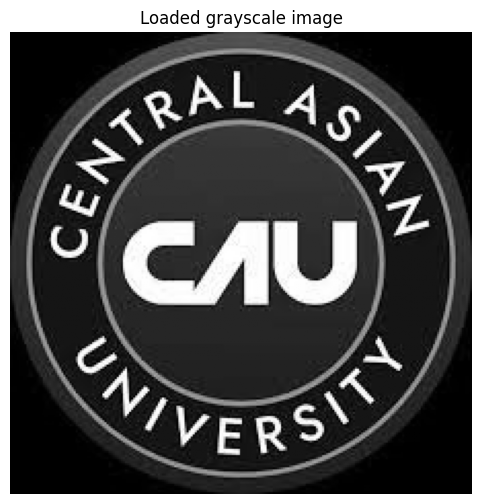

In [ ]:
# Uncomment and modify this if you want to load your own image:

image_path = "/content/drive/MyDrive/Recent Codes/images.jpg"
image = Image.open(image_path).convert("L")
image = np.array(image)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Loaded grayscale image")
plt.axis("off")
plt.show()

## 3. Explore intensity values

Before thresholding, it is useful to look at the histogram of pixel intensities.

A histogram tells us how many pixels fall into each intensity range.  
If the object and background are well separated, the histogram may show different peaks.

This helps us choose a threshold $T$.

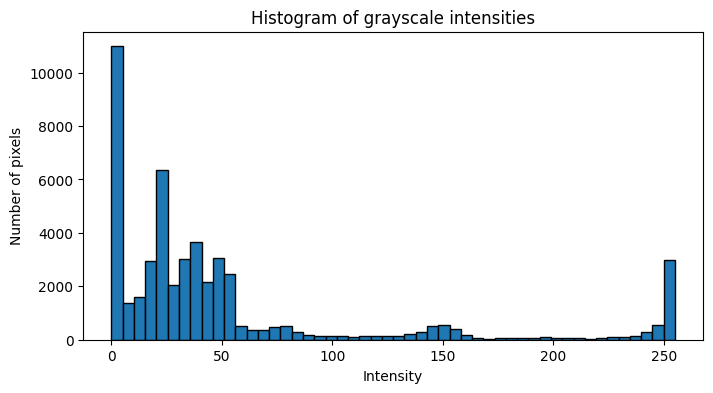

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(image.ravel(), bins=50, edgecolor="black")
plt.title("Histogram of grayscale intensities")
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.show()

## 4. Image segmentation using global thresholding

### Method

A **global threshold** uses a single value $T$ for the whole image.

The segmentation rule is:

$$
M(x,y) =
\begin{cases}
1, & I(x,y) \ge T \\
0, & I(x,y) < T
\end{cases}
$$

### Interpretation

- pixels brighter than the threshold become **foreground**
- pixels darker than the threshold become **background**

### Advantages
- simple
- fast
- easy to implement

### Limitations
- sensitive to lighting variation
- sensitive to noise
- may fail if foreground and background intensities overlap

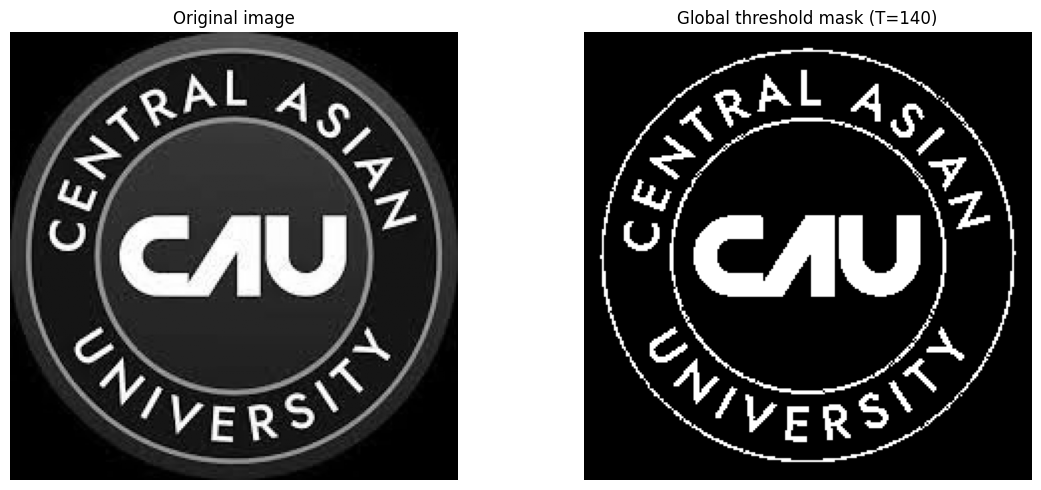

In [ ]:
def global_threshold(image, T):
    return (image >= T).astype(np.uint8)

T = 140
mask_global = global_threshold(image, T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"Original image")
axes[0].axis("off")

axes[1].imshow(mask_global, cmap="gray")
axes[1].set_title(f"Global threshold mask (T={T})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Understanding mask generation

A **mask** is a binary image that tells us which pixels belong to a selected region.

Usually:
- `1` means **selected / foreground**
- `0` means **not selected / background**

Masks are important because they let us:
- isolate an object
- measure an object's area
- apply operations only inside a region
- overlay segmentation results on the original image

### Mathematical view

If $M(x,y)$ is the mask and $I(x,y)$ is the image, then the masked image can be expressed as:

$$
I_{\text{masked}}(x,y) = I(x,y)\cdot M(x,y)
$$

This keeps only the pixels where the mask is 1.

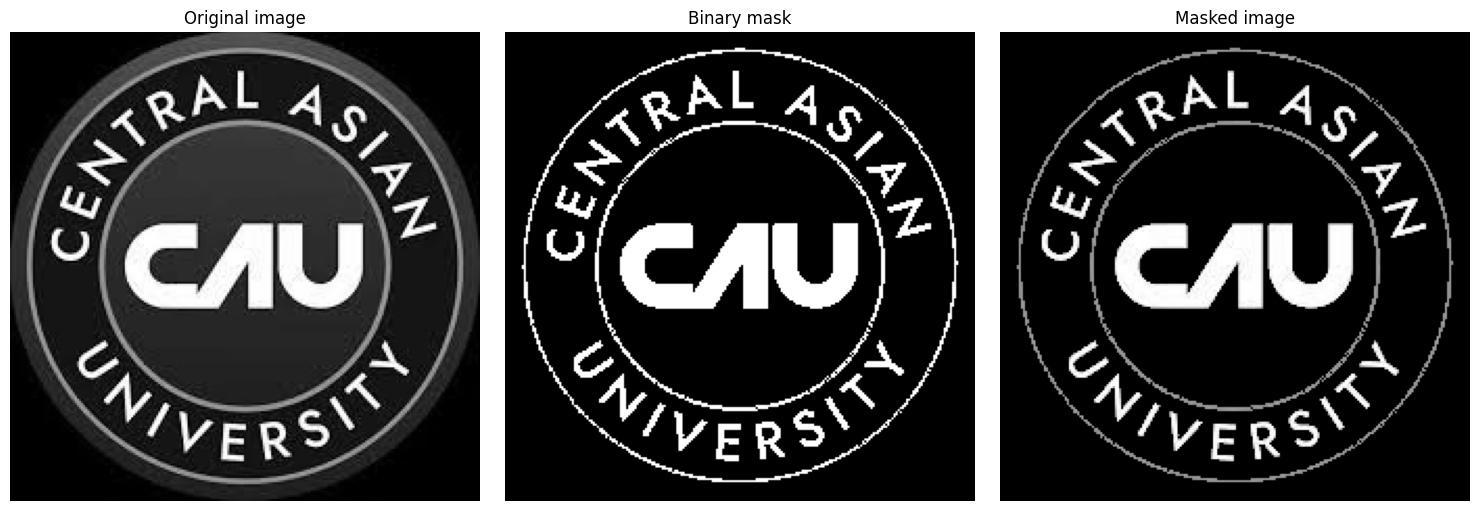

In [ ]:
masked_image = image * mask_global

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(mask_global, cmap="gray")
axes[1].set_title("Binary mask")
axes[1].axis("off")

axes[2].imshow(masked_image, cmap="gray")
axes[2].set_title("Masked image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 6. A reusable function for segmentation and mask generation

The next cell wraps the thresholding step into a reusable function.  
This is useful when students want to test several threshold values.

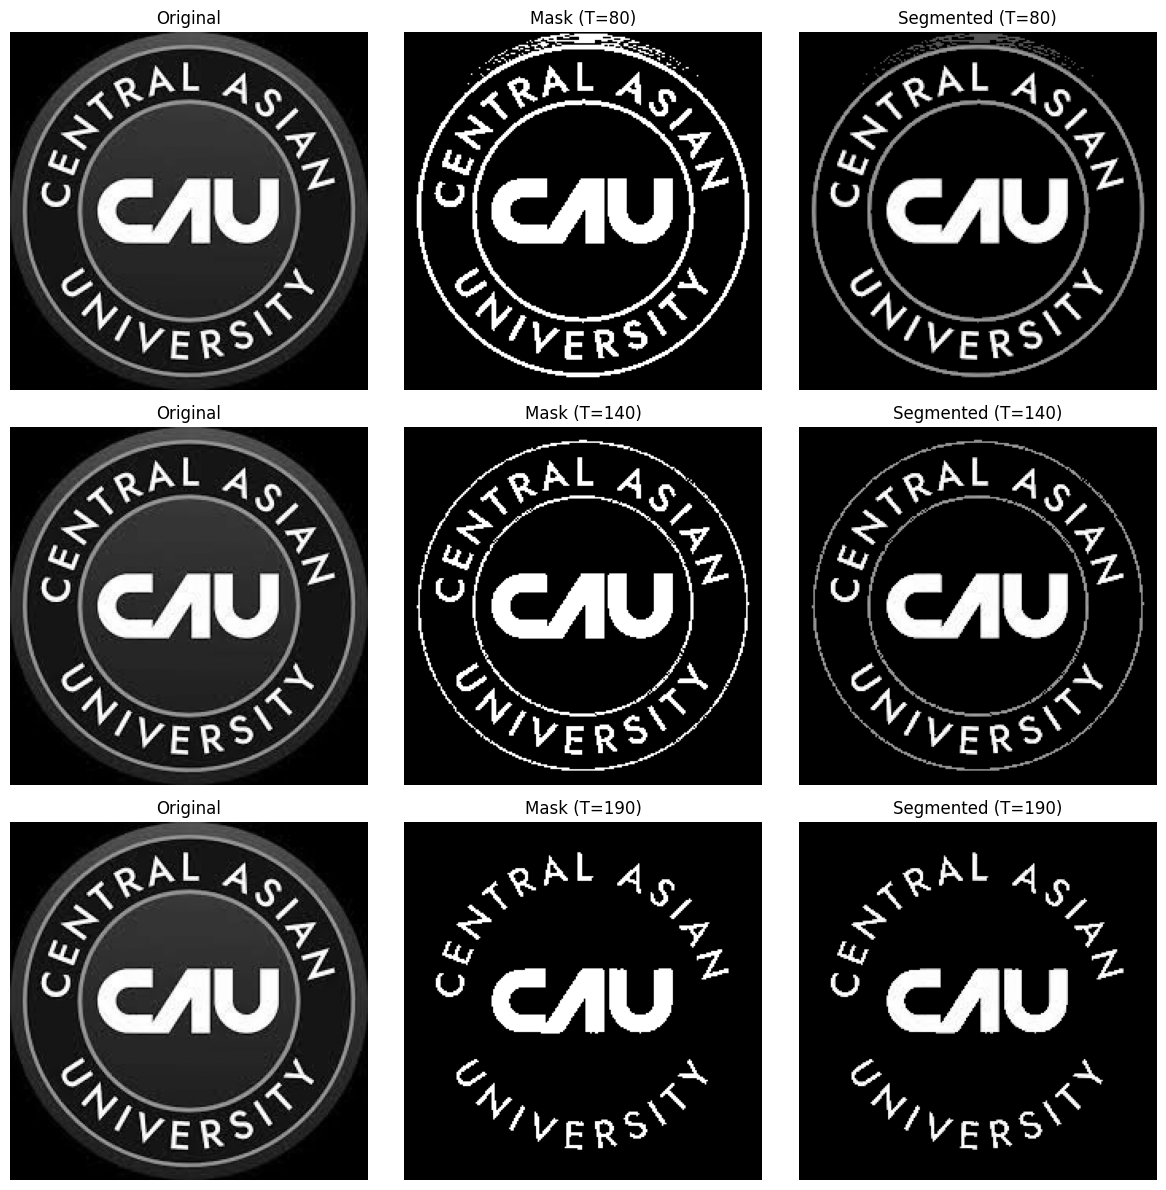

In [ ]:
def segment_and_mask(image, threshold):
    mask = (image >= threshold).astype(np.uint8)
    segmented = image * mask
    return mask, segmented

test_thresholds = [80, 140, 190]

fig, axes = plt.subplots(len(test_thresholds), 3, figsize=(12, 12))

for i, thr in enumerate(test_thresholds):
    mask, segmented = segment_and_mask(image, thr)

    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Mask (T={thr})")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(segmented, cmap="gray")
    axes[i, 2].set_title(f"Segmented (T={thr})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 7. Discussion: effect of threshold value

The threshold value strongly affects segmentation quality.

### If the threshold is too low:
- too many pixels become foreground
- background noise may be included

### If the threshold is too high:
- parts of the true object may disappear
- segmentation becomes incomplete

### In practice
A good threshold depends on:
- object brightness
- background brightness
- image contrast
- noise level
- illumination consistency

For real applications, manual thresholding is often replaced by:
- Otsu thresholding
- adaptive thresholding
- clustering methods
- machine learning or deep learning segmentation

## 8. Edge detection with gradients

Segmentation finds regions.  
**Edge detection** finds boundaries where intensity changes sharply.

An edge usually occurs where the image intensity changes rapidly in space.

### Gradient definition

The image gradient has two components:

$$
G_x = \frac{\partial I}{\partial x}, \qquad
G_y = \frac{\partial I}{\partial y}
$$

Where:
- $G_x$ measures horizontal intensity change
- $G_y$ measures vertical intensity change

The **gradient magnitude** is:

$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}
$$

A large gradient magnitude suggests a strong edge.

### Edge thresholding

After computing the gradient magnitude, we threshold it:

$$
E(x,y) =
\begin{cases}
1, & |\nabla I(x,y)| \ge T_e \\
0, & |\nabla I(x,y)| < T_e
\end{cases}
$$

Where $T_e$ is the edge threshold.

## 9. Sobel filters for gradient estimation

A practical way to estimate image gradients is to use **Sobel kernels**.

Horizontal Sobel kernel:

$$
S_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

Vertical Sobel kernel:

$$
S_y =
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$

Convolving the image with these kernels gives approximate gradients:

$$
G_x = I * S_x,\qquad G_y = I * S_y
$$

Where $*$ denotes convolution.

In [ ]:
def convolve2d(image, kernel):
    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)

    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    out = np.zeros_like(image, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)

    return out

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

Gx = convolve2d(image, sobel_x)
Gy = convolve2d(image, sobel_y)
gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

## 10. Visualize gradients and gradient magnitude

These visualizations help explain how each stage contributes to edge detection.

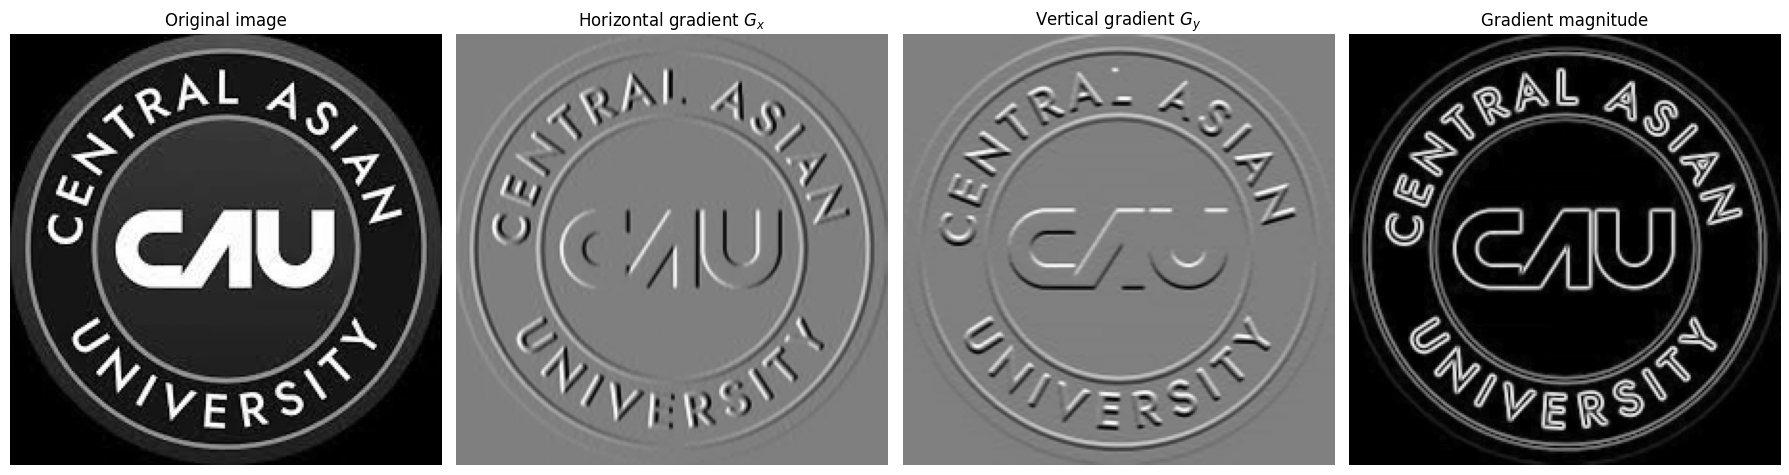

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(Gx, cmap="gray")
axes[1].set_title("Horizontal gradient $G_x$")
axes[1].axis("off")

axes[2].imshow(Gy, cmap="gray")
axes[2].set_title("Vertical gradient $G_y$")
axes[2].axis("off")

axes[3].imshow(gradient_magnitude, cmap="gray")
axes[3].set_title("Gradient magnitude")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## 11. Threshold the gradient magnitude to obtain edges

Now we convert the gradient magnitude into a binary edge image.

Pixels with strong enough gradient are marked as edges.

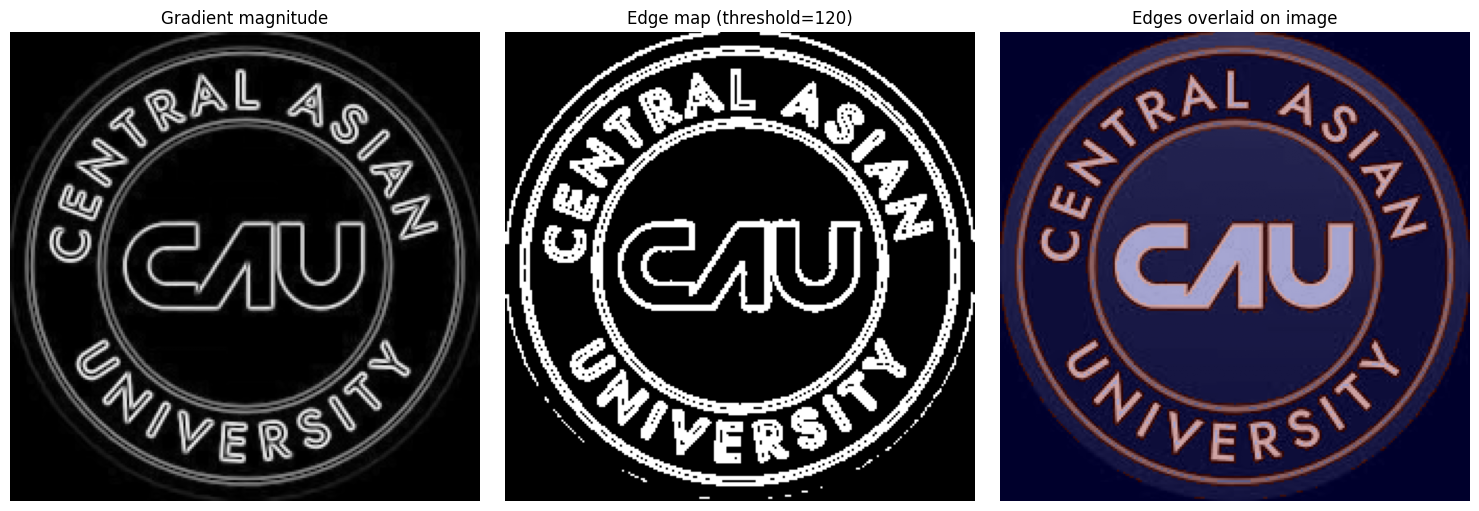

In [ ]:
edge_threshold = 120
edges = (gradient_magnitude >= edge_threshold).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gradient_magnitude, cmap="gray")
axes[0].set_title("Gradient magnitude")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title(f"Edge map (threshold={edge_threshold})")
axes[1].axis("off")

axes[2].imshow(image, cmap="gray")
axes[2].imshow(edges, cmap="jet", alpha=0.35)
axes[2].set_title("Edges overlaid on image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 12. Compare different edge thresholds

As with segmentation, threshold selection matters.

- low threshold -> more edges, but more noise
- high threshold -> cleaner result, but weaker edges may disappear

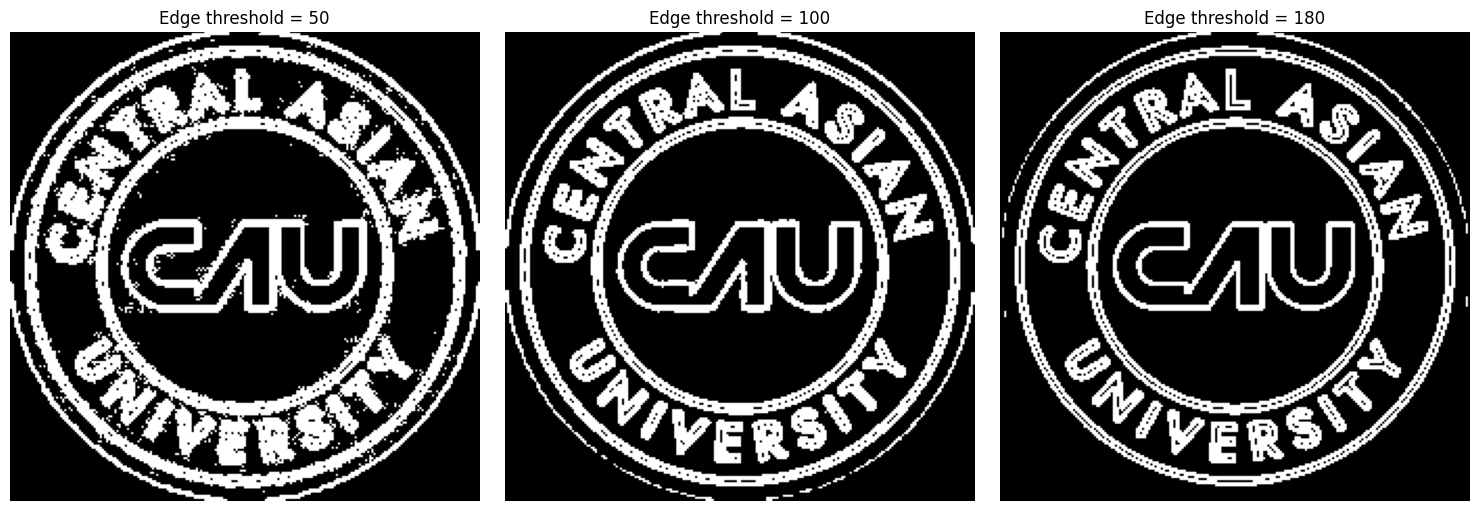

In [ ]:
edge_thresholds = [50, 100, 180]

fig, axes = plt.subplots(1, len(edge_thresholds), figsize=(15, 5))

for ax, thr in zip(axes, edge_thresholds):
    e = (gradient_magnitude >= thr).astype(np.uint8)
    ax.imshow(e, cmap="gray")
    ax.set_title(f"Edge threshold = {thr}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 13. Summary of methods

### A. Global thresholding
Used to separate foreground from background using one intensity threshold.

$$
M(x,y) =
\begin{cases}
1, & I(x,y) \ge T \\
0, & I(x,y) < T
\end{cases}
$$

### B. Mask generation
Used to isolate or preserve the selected region.

$$
I_{\text{masked}}(x,y) = I(x,y)\cdot M(x,y)
$$

### C. Edge detection using gradients
Uses local intensity changes to find boundaries.

$$
G_x = \frac{\partial I}{\partial x}, \qquad G_y = \frac{\partial I}{\partial y}
$$

$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}
$$

$$
E(x,y) =
\begin{cases}
1, & |\nabla I(x,y)| \ge T_e \\
0, & |\nabla I(x,y)| < T_e
\end{cases}
$$

---

## When to use each method

### Use thresholding when:
- object and background have clearly different brightness
- you want a fast and simple segmentation

### Use edge detection when:
- you want object boundaries
- region intensity varies but boundary contrast is strong

### Often in practice:
Thresholding and edge detection are used together as complementary tools.

## 14. Real-world effects and limitations

### 1. Noise
Noise creates unwanted intensity variations, which may:
- break segmentation
- create false edges

### 2. Uneven illumination
A single global threshold may fail if one side of the image is brighter than the other.

### 3. Weak boundaries
If the boundary between object and background is subtle, gradients may be too small.

### 4. Blur
Blur smooths intensity changes and weakens edges.

### 5. Texture
Highly textured regions may create many gradients, even when there is no meaningful object boundary.

---

## Improvement ideas

Students can later explore:
- Gaussian smoothing before edge detection
- Otsu thresholding
- adaptive thresholding
- Canny edge detection
- morphological operations such as erosion and dilation

## 15. Conclusion

This notebook demonstrated:

- **image segmentation using global thresholding**
- **mask generation for segmented regions**
- **edge detection using gradients and thresholding**

These are core concepts in digital image processing and form the basis for many advanced methods in computer vision, medical imaging, robotics, and remote sensing.

A strong understanding of these basics makes it much easier to study more advanced methods later.

# Student Tasks and Challenges

The following tasks extend the lab and are intended to test understanding of thresholding, mask generation, and edge detection.

Complete each task in a new code cell underneath the instructions.


## Task 1: Try Different Threshold Values

Run the segmentation with at least five different threshold values.

Suggested values: `60`, `100`, `140`, `180`, `220`

For each threshold:
- Display the binary mask
- Comment on what changes
- Identify which threshold gives the best separation between object and background


In [ ]:
thresholds = [60, 100, 140, 180, 220]

fig, axes = plt.subplots(1, len(thresholds), figsize=(18,4))

for i, T in enumerate(thresholds):
    mask = global_threshold(image, T)
    axes[i].imshow(mask, cmap="gray")
    axes[i].set_title(f"T = {T}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Task 2: Build Your Own Segmentation Function

Write a function called `my_threshold(image, T)` without copying the earlier function.

Requirements:
- Use a `for` loop or nested loops
- Assign `1` to pixels greater than or equal to `T`
- Assign `0` otherwise

Then compare the result with the original `global_threshold()` function.


In [ ]:
# Write your code below

def my_threshold(image, T):
    pass

student_mask = my_threshold(image, 140)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(student_mask, cmap="gray")
plt.title("Student Function")

plt.subplot(1,2,2)
plt.imshow(global_threshold(image, 140), cmap="gray")
plt.title("Reference Function")
plt.show()


## Task 3: Noise Challenge

Increase the amount of noise in the synthetic image.

Questions:
1. What happens to the mask?
2. Does the same threshold still work?
3. What could you do to improve the result?


## Challenge 1: Automatic Threshold Selection

Instead of choosing the threshold manually, use Otsu's method from `skimage.filters`.

Steps:
- Import `threshold_otsu`
- Compute the best threshold automatically
- Compare the automatic result with your manual threshold


In [ ]:
from skimage.filters import threshold_otsu

T_otsu = threshold_otsu(image)
print("Automatic threshold:", T_otsu)

mask_otsu = image >= T_otsu

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(mask_otsu, cmap="gray")
plt.title(f"Otsu Threshold = {T_otsu}")
plt.show()


## Challenge 2: Count the Number of White Pixels

After generating the mask:
- Count how many pixels belong to the foreground
- Compute the percentage of the image that is selected
- Print the result


In [ ]:
foreground_pixels = np.sum(mask_global)
total_pixels = mask_global.size
percentage = 100 * foreground_pixels / total_pixels

print("Foreground pixels:", foreground_pixels)
print("Percentage selected:", round(percentage, 2), "%")


## Challenge 3: Edge Detection Comparison

Apply two different edge detection methods:
- Sobel
- Canny

Then answer:
- Which method gives cleaner edges?
- Which one is more sensitive to noise?


In [ ]:
from skimage.filters import sobel
from skimage.feature import canny

edges_sobel = sobel(image)
edges_canny = canny(image / 255.0)

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].imshow(edges_sobel, cmap="gray")
axes[0].set_title("Sobel")

axes[1].imshow(edges_canny, cmap="gray")
axes[1].set_title("Canny")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Final Mini Project

Choose one of the following:

1. Load a real medical image and segment the suspicious region.
2. Create your own synthetic image with at least three objects and different intensity values.
3. Build a small pipeline:
   - Load image
   - Apply thresholding
   - Generate mask
   - Detect edges
   - Save the result

Deliverables:
- Your code
- At least 3 figures
- A short written explanation of your observations


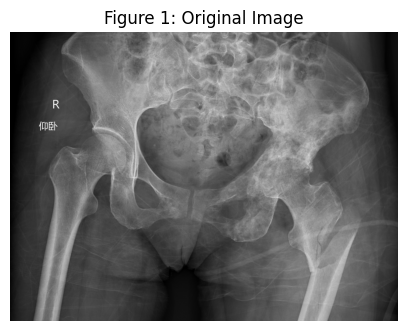

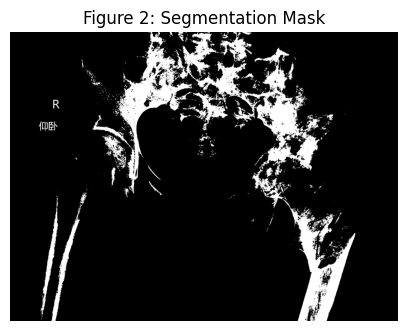

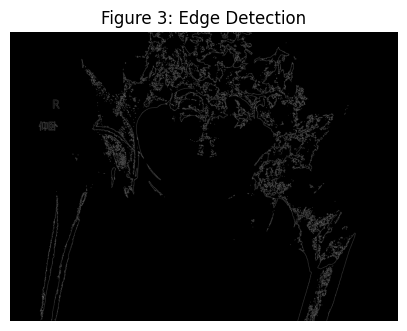

In [ ]:


import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# 1. Read the image
# --------------------------------
image = cv2.imread("/content/drive/MyDrive/Recent Codes/IMG000001.jpeg", cv2.IMREAD_GRAYSCALE)

# --------------------------------
# 2. Apply thresholding
# --------------------------------
# Pixels brighter than 150 become white, others become black
_, mask = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY)

# --------------------------------
# 3. Detect edges
# --------------------------------
edges = cv2.Canny(mask, 50, 150)

# --------------------------------
# 4. Save the results
# --------------------------------
cv2.imwrite("output_mask.png", mask)
cv2.imwrite("output_edges.png", edges)

# --------------------------------
# 5. Show Figure 1: Original image
# --------------------------------
plt.figure(figsize=(5,5))
plt.imshow(image, cmap="gray")
plt.title("Figure 1: Original Image")
plt.axis("off")
plt.show()

# --------------------------------
# 6. Show Figure 2: Mask
# --------------------------------
plt.figure(figsize=(5,5))
plt.imshow(mask, cmap="gray")
plt.title("Figure 2: Segmentation Mask")
plt.axis("off")
plt.show()

# --------------------------------
# 7. Show Figure 3: Edges
# --------------------------------
plt.figure(figsize=(5,5))
plt.imshow(edges, cmap="gray")
plt.title("Figure 3: Edge Detection")
plt.axis("off")
plt.show()

# --------------------------------
# 8. Optional: show overlay
# --------------------------------
plt.figure(figsize=(5,5))
plt.imshow(image, cmap="gray")
plt.contour(mask, colors="red", linewidths=1)
plt.title("Figure 4: Mask on Original Image")
plt.axis("off")
plt.show()